# 🛠️ Feature Engineering — Nivel Senior Empresarial
## Proyecto: *Conociendo al Cliente 360°* — InsightReach Analytics
### Notebook 03: Creación, Transformación y Selección de Variables para ML

---

| Campo | Detalle |
|-------|--------|
| **👤 Autor** | Dody Dueñas |
| **📅 Fecha** | Abril 2026 |
| **🎯 Versión** | 2.0 — Estándar Senior Empresarial |
| **📥 Input** | `data/processed/customers_clean.csv` + `yelp_clean.csv` |
| **📤 Output** | `data/processed/customers_features.csv` |

---

## 🎯 Contexto y Justificación

El Feature Engineering es el proceso más **creativo y de mayor impacto** en un proyecto de Machine Learning. Los modelos son tan buenos como los datos que reciben — y los datos crudos raramente capturan toda la complejidad del comportamiento humano.

En este notebook creamos **features derivadas** que capturan patrones que los algoritmos no pueden detectar directamente:

| Tipo de Feature | Ejemplo | ¿Por qué es valioso? |
|----------------|---------|---------------------|
| **Demográficas** | `grupo_etario`, `generacion` | Los hábitos de consumo varían radicalmente por cohorte generacional |
| **Económicas** | `ratio_gasto_ingreso`, `ltv_mensual` | Capturan el comportamiento financiero real vs. el nivel de ingresos |
| **Comportamentales** | `engagement_score`, `es_visitante_freq` | Predicen mejor el gasto futuro que datos demográficos |
| **Geográficas** | `ratio_mercado_ciudad` | Contextualizan al cliente en su entorno competitivo |
| **Codificaciones** | `pref_vegetariano`, `es_premium` | Convierten variables categóricas en señales numéricas para ML |

---

## 🗺️ Mapa del Notebook

| # | Fase | Técnica |
|---|------|---------|
| **1** | Configuración | Imports, rutas, carga de datos |
| **2** | Features Demográficas | Binning de edad, generación, grupos |
| **3** | Features Económicas | Ratios, clasificaciones, LTV |
| **4** | Features Comportamentales | Engagement, frecuencia, scoring |
| **5** | Features Geográficas | Enriquecimiento con datos Yelp |
| **6** | Codificación Categórica | One-hot, label, ordinal encoding |
| **7** | Selección de Features | Correlación, K-Best, Importancia RF |
| **8** | Exportación | Dataset final para modelado |

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 1: CONFIGURACIÓN DEL ENTORNO                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
sns.set_context('notebook', font_scale=1.1)

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#A23B72',
    'accent':    '#F18F01',
    'success':   '#2DC653',
    'danger':    '#E84855',
    'neutral':   '#6c757d',
}

plt.rcParams.update({
    'figure.figsize': (14, 8), 'figure.dpi': 100,
    'savefig.dpi': 300, 'axes.titlesize': 14,
    'axes.titleweight': 'bold', 'axes.labelsize': 12,
})

sys.path.insert(0, '..')
# --- Deteccion robusta de la raiz del proyecto ---
import os
from pathlib import Path
try:
    # Si estamos en un notebook
    current_path = Path(os.path.abspath('')).resolve()
except:
    # Si estamos en un script
    current_path = Path(__file__).parent.resolve()

if (current_path / 'notebooks').exists():
    ROOT_DIR = current_path
elif (current_path.parent / 'notebooks').exists():
    ROOT_DIR = current_path.parent
else:
    # Fallback extremo
    ROOT_DIR = Path(r"c:\Users\DODY DUEÑAS\Documents\ProyectodeHenry\Proyecto_Integrador_Dody_Empresarial")

DATA_RAW       = ROOT_DIR / 'data' / 'raw'
DATA_PROCESSED = ROOT_DIR / 'data' / 'processed'
DATA_EXTERNAL  = ROOT_DIR / 'data' / 'external'
REPORTS_FIGS   = ROOT_DIR / 'reports' / 'figures'
REPORTS_TABS   = ROOT_DIR / 'reports' / 'tables'

# Crear directorios si no existen
for p in [DATA_PROCESSED, DATA_EXTERNAL, REPORTS_FIGS, REPORTS_TABS]:
    p.mkdir(parents=True, exist_ok=True)



RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Importación defensiva de módulos del proyecto
try:
    from config.settings import Settings
    from src.features.builders import CustomerFeatureBuilder
    from src.features.selectors import FeatureSelector
    PROJECT_MODULES_LOADED = True
    print('✅ Módulos del proyecto cargados')
except ImportError as e:
    print(f'⚠️  Modo standalone — feature engineering manual activo: {e}')
    PROJECT_MODULES_LOADED = False
    
    class Settings:
        RANDOM_STATE = 42
        TEST_SIZE    = 0.2

print('\n' + '═' * 75)
print('  ✅ ENTORNO CONFIGURADO — Feature Engineering v2.0')
print('═' * 75)
print(f'  📅 Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('═' * 75)

✅ Módulos del proyecto cargados

═══════════════════════════════════════════════════════════════════════════
  ✅ ENTORNO CONFIGURADO — Feature Engineering v2.0
═══════════════════════════════════════════════════════════════════════════
  📅 Timestamp: 2026-04-09 12:56:43
═══════════════════════════════════════════════════════════════════════════


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 2: CARGA DE DATOS DEL PIPELINE                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  📥 CARGA DE DATOS LIMPIOS')
print('═' * 75)

# Cargar dataset de clientes (output del NB01)
customers_path = DATA_PROCESSED / 'customers_clean.csv'
if not customers_path.exists():
    raise FileNotFoundError(
        f'Archivo no encontrado: {customers_path}\n'
        '📌 Ejecute primero el Notebook 01 (EDA).'
    )

df = pd.read_csv(customers_path, low_memory=False)
n_original = len(df)

print(f'  ✅ customers_clean.csv : {len(df):,} registros × {len(df.columns)} columnas')

# Cargar datos de Yelp si existen
yelp_path = DATA_PROCESSED / 'yelp_clean.csv'
YELP_DISPONIBLE = yelp_path.exists()
if YELP_DISPONIBLE:
    df_yelp = pd.read_csv(yelp_path)
    print(f'  ✅ yelp_clean.csv      : {len(df_yelp):,} registros × {len(df_yelp.columns)} columnas')

# Cargar comparación de mercado
comp_path = DATA_PROCESSED / 'market_comparison.csv'
COMP_DISPONIBLE = comp_path.exists()
if COMP_DISPONIBLE:
    df_comp = pd.read_csv(comp_path, index_col=0)
    print(f'  ✅ market_comparison   : {len(df_comp):,} ciudades')

print('\n  📋 Variables disponibles en customers_clean:')
for col in df.columns:
    n_nulos = df[col].isnull().sum()
    print(f'    • {col:<36} {str(df[col].dtype):<12} ({n_nulos} nulos)')


═══════════════════════════════════════════════════════════════════════════
  📥 CARGA DE DATOS LIMPIOS
═══════════════════════════════════════════════════════════════════════════
  ✅ customers_clean.csv : 30,000 registros × 18 columnas
  ✅ yelp_clean.csv      : 463 registros × 14 columnas
  ✅ market_comparison   : 10 ciudades

  📋 Variables disponibles en customers_clean:
    • id_persona                           int64        (0 nulos)
    • nombre                               object       (0 nulos)
    • apellido                             object       (0 nulos)
    • edad                                 int64        (0 nulos)
    • genero                               object       (0 nulos)
    • ciudad_residencia                    object       (0 nulos)
    • estrato_socioeconomico               object       (0 nulos)
    • frecuencia_visita                    int64        (0 nulos)
    • promedio_gasto_comida                float64      (0 nulos)
    • ocio                    

---

# 🔧 FASE 2: Features Demográficas

## ¿Por qué la edad no basta?: El poder de la Cohorte Generacional

La edad como número continuo tiene limitada capacidad predictiva porque el comportamiento de consumo no es lineal con la edad — hay **saltos cualitativos** en rangos específicos:

| Generación | Rango | Características de consumo gastronómico |
|-----------|---------|-----------------------------------------|
| **Gen Z** | 18-27 | Apps, delivery, experiencias, redes sociales |
| **Millennials** | 28-43 | Calidad-precio, sostenibilidad, brunch |
| **Gen X** | 44-59 | Fidelidad, eventos corporativos, vino |
| **Boomers** | 60+  | Servicio premium, tradición, fine dining |

---

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 3: FEATURES DEMOGRÁFICAS                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🔧 FASE 2: FEATURES DEMOGRÁFICAS')
print('═' * 75)

features_log = []  # Log de features creadas

if 'edad' in df.columns:
    # 1. Grupo etario granular (6 bins)
    df['grupo_etario'] = pd.cut(
        df['edad'],
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    )
    features_log.append(('grupo_etario', 'Categórica', 'Segmentación por cohorte etaria (6 grupos)'))
    
    # 2. Generación histórica
    current_year = 2026
    birth_year   = current_year - df['edad']
    df['generacion'] = pd.cut(
        birth_year,
        bins=[1900, 1964, 1979, 1994, 2009, 2026],
        labels=['Boomer', 'GenX', 'Millennial', 'GenZ', 'Alpha'],
        right=False
    )
    features_log.append(('generacion', 'Categórica', 'Cohorte generacional (Boomer→Alpha)'))
    
    # 3. Indicadores binarios
    df['es_joven']  = (df['edad'] <= 35).astype(int)
    df['es_adulto'] = ((df['edad'] > 35) & (df['edad'] <= 55)).astype(int)
    df['es_senior'] = (df['edad'] > 55).astype(int)
    features_log.extend([
        ('es_joven',  'Binaria', 'Edad ≤ 35 años'),
        ('es_adulto', 'Binaria', '35 < Edad ≤ 55 años'),
        ('es_senior', 'Binaria', 'Edad > 55 años'),
    ])

if 'genero' in df.columns:
    df['es_masculino'] = (df['genero'].str.lower().str.contains('m', na=False) &
                         ~df['genero'].str.lower().str.contains('fem', na=False)).astype(int)
    features_log.append(('es_masculino', 'Binaria', 'Género masculino (1=Sí)'))

print(f'  ✅ Features demográficas creadas: {len([f for f in features_log if f in features_log])}')
for name, tipo, desc in features_log:
    print(f'  ├── {name:<30} [{tipo:<12}] {desc}')


═══════════════════════════════════════════════════════════════════════════
  🔧 FASE 2: FEATURES DEMOGRÁFICAS
═══════════════════════════════════════════════════════════════════════════
  ✅ Features demográficas creadas: 6
  ├── grupo_etario                   [Categórica  ] Segmentación por cohorte etaria (6 grupos)
  ├── generacion                     [Categórica  ] Cohorte generacional (Boomer→Alpha)
  ├── es_joven                       [Binaria     ] Edad ≤ 35 años
  ├── es_adulto                      [Binaria     ] 35 < Edad ≤ 55 años
  ├── es_senior                      [Binaria     ] Edad > 55 años
  ├── es_masculino                   [Binaria     ] Género masculino (1=Sí)


---

# 💰 FASE 3: Features Económicas

## Más allá de los Ingresos: El Ratio de Gasto

Un cliente con $5,000/mes de ingreso que gasta $200 en comida vs. un cliente con $3,000/mes que gasta $200 son **fundamentalmente diferentes** en comportamiento. El ratio es más informativo que el valor absoluto.

Igualmente, el **LTV mensual estimado** (Lifetime Value) es el KPI que los restaurantes y agencias de marketing más valoran para priorizar campañas.

---

In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 4: FEATURES ECONÓMICAS                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  💰 FASE 3: FEATURES ECONÓMICAS')
print('═' * 75)

eco_features = []

# 1. Ingresos anuales estimados
if 'ingresos_mensuales' in df.columns:
    df['ingresos_anuales'] = df['ingresos_mensuales'] * 12
    eco_features.append(('ingresos_anuales', 'Numérica', 'Ingresos × 12'))
    
    # 2. Categoría de ingreso (cuartiles)
    df['categoria_ingreso'] = pd.qcut(
        df['ingresos_mensuales'],
        q=4,
        labels=['Q1_Bajo', 'Q2_MedioBajo', 'Q3_MedioAlto', 'Q4_Alto'],
        duplicates='drop'
    )
    eco_features.append(('categoria_ingreso', 'Categórica', 'Cuartil de ingresos'))

# 3. Ratio gasto / ingreso
if 'promedio_gasto_comida' in df.columns and 'ingresos_mensuales' in df.columns:
    df['ratio_gasto_ingreso'] = np.where(
        df['ingresos_mensuales'] > 0,
        df['promedio_gasto_comida'] / df['ingresos_mensuales'],
        0
    ).round(4)
    eco_features.append(('ratio_gasto_ingreso', 'Numérica', 'Gasto / Ingreso mensual'))

# 4. LTV mensual estimado (Gasto × Frecuencia)
if 'promedio_gasto_comida' in df.columns and 'frecuencia_visita' in df.columns:
    df['ltv_mensual'] = (df['promedio_gasto_comida'] * df['frecuencia_visita']).round(2)
    eco_features.append(('ltv_mensual', 'Numérica', 'Gasto × Frecuencia mensual'))
    
    # 5. LTV anual estimado
    df['ltv_anual'] = (df['ltv_mensual'] * 12).round(2)
    eco_features.append(('ltv_anual', 'Numérica', 'LTV proyectado a 12 meses'))

# 6. Log-transformación de variables con alta asimetría (para ML)
for col_base in ['ingresos_mensuales', 'promedio_gasto_comida', 'ltv_mensual']:
    if col_base in df.columns:
        vals = df[col_base].fillna(0)
        if (vals > 0).all():
            df[f'log_{col_base}'] = np.log1p(vals).round(4)
            eco_features.append((f'log_{col_base}', 'Numérica', f'log(1 + {col_base}) — normaliza distribución'))

# 7. Clasificación de perfil económico
if 'estrato_socioeconomico' in df.columns:
    estrato_map = {'Bajo': 1, 'Medio': 2, 'Alto': 3, 'Muy Alto': 4}
    df['estrato_num'] = df['estrato_socioeconomico'].map(estrato_map).fillna(2)
    eco_features.append(('estrato_num', 'Ordinal', 'Estrato NSE codificado (1=Bajo, 4=Muy Alto)'))

features_log.extend(eco_features)
print(f'  ✅ Features económicas creadas: {len(eco_features)}')
for name, tipo, desc in eco_features:
    print(f'  ├── {name:<30} [{tipo:<12}] {desc}')

# Estadísticas de las nuevas features
new_num_feats = ['ratio_gasto_ingreso', 'ltv_mensual', 'ltv_anual']
new_num_disp  = [c for c in new_num_feats if c in df.columns]
if new_num_disp:
    print('\n  📊 Estadísticas de features económicas:')
    display(df[new_num_disp].describe().round(2))


═══════════════════════════════════════════════════════════════════════════
  💰 FASE 3: FEATURES ECONÓMICAS
═══════════════════════════════════════════════════════════════════════════
  ✅ Features económicas creadas: 7
  ├── ingresos_anuales               [Numérica    ] Ingresos × 12
  ├── categoria_ingreso              [Categórica  ] Cuartil de ingresos
  ├── ratio_gasto_ingreso            [Numérica    ] Gasto / Ingreso mensual
  ├── ltv_mensual                    [Numérica    ] Gasto × Frecuencia mensual
  ├── ltv_anual                      [Numérica    ] LTV proyectado a 12 meses
  ├── log_ingresos_mensuales         [Numérica    ] log(1 + ingresos_mensuales) — normaliza distribución
  ├── estrato_num                    [Ordinal     ] Estrato NSE codificado (1=Bajo, 4=Muy Alto)

  📊 Estadísticas de features económicas:


,ratio_gasto_ingreso,ltv_mensual,ltv_anual
count,30000.00,30000.00,30000.00
mean,0.01,173.40,2080.84
std,0.00,205.12,2461.46
min,0.00,0.00,0.00
25%,0.00,40.72,488.61
50%,0.01,102.76,1233.06
75%,0.01,223.95,2687.40
max,0.03,1499.70,17996.40


---

# 🎯 FASE 4: Features Comportamentales — Engagement Score

## Construyendo el Score de Engagement

El **Engagement Score** es un KPI compuesto que mide **cuán comprometido está un cliente** con el ecosistema de restaurantes. Se construye como un promedio ponderado de múltiples señales normalizadas:

```
Engagement Score = 0.35×(frecuencia_norm) + 0.30×(gasto_norm) + 0.20×(premium_flag) + 0.15×(pago_digital)
```

**Justificación de pesos**: La frecuencia de visita es la señal más fuerte de engagement (35%), seguida del nivel de gasto absoluto (30%). La membresía premium es un indicador de lealtad declarada (20%) y el uso de pago digital refleja adopción tecnológica (15%).

---

In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 5: FEATURES COMPORTAMENTALES — ENGAGEMENT                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🎯 FASE 4: FEATURES COMPORTAMENTALES')
print('═' * 75)

comp_features = []

def normalizar_min_max(serie: pd.Series) -> pd.Series:
    """Normalización min-max robusta (ignora NaN)."""
    mn, mx = serie.min(), serie.max()
    if mx == mn:
        return pd.Series(0.5, index=serie.index)
    return ((serie - mn) / (mx - mn)).clip(0, 1)

# 1. Frecuencia de visita categorizada
if 'frecuencia_visita' in df.columns:
    df['frecuencia_categoria'] = pd.cut(
        df['frecuencia_visita'],
        bins=[-1, 3, 7, 14, 1000],
        labels=['Esporádico', 'Ocasional', 'Regular', 'Frecuente']
    )
    df['es_visitante_frecuente'] = (df['frecuencia_visita'] > df['frecuencia_visita'].median()).astype(int)
    comp_features.extend([
        ('frecuencia_categoria',    'Categórica', 'Categoría de frecuencia de visita'),
        ('es_visitante_frecuente',  'Binaria',    'Frecuencia > mediana (1=Sí)'),
    ])

# 2. Membresía Premium (binaria)
if 'membresia_premium' in df.columns:
    col_si = 'Sí' if 'Sí' in df['membresia_premium'].values else 'Si'
    df['es_premium'] = (df['membresia_premium'] == col_si).astype(int)
    comp_features.append(('es_premium', 'Binaria', 'Membresía premium activa'))

# 3. Pago digital (1 si usa app/tarjeta versus efectivo)
if 'tipo_de_pago_mas_usado' in df.columns:
    pagos_digitales = ['Tarjeta de Crédito', 'Tarjeta de Débito', 'Aplicación Móvil',
                       'Tarjeta', 'Digital', 'App', 'Crédito', 'Débito']
    df['pago_digital'] = df['tipo_de_pago_mas_usado'].apply(
        lambda x: int(any(p.lower() in str(x).lower() for p in pagos_digitales))
    )
    comp_features.append(('pago_digital', 'Binaria', 'Usa método de pago digital'))

# 4. Consumo de licor (indicador de gasto potencial mayor)
if 'consume_licor' in df.columns:
    df['consume_licor_bin'] = (df['consume_licor'].str.lower().str.strip()
                                .isin(['sí', 'si', 'yes', 's'])).astype(int)
    comp_features.append(('consume_licor_bin', 'Binaria', 'Consume licor (mayor ticket promedio)'))

# 5. Engagement Score Compuesto (0-1)
componentes = {}
pesos = {}

if 'frecuencia_visita' in df.columns:
    componentes['frec_norm'] = normalizar_min_max(df['frecuencia_visita'])
    pesos['frec_norm'] = 0.35

if 'promedio_gasto_comida' in df.columns:
    componentes['gasto_norm'] = normalizar_min_max(df['promedio_gasto_comida'])
    pesos['gasto_norm'] = 0.30

if 'es_premium' in df.columns:
    componentes['premium'] = df['es_premium'].astype(float)
    pesos['premium'] = 0.20

if 'pago_digital' in df.columns:
    componentes['digital'] = df['pago_digital'].astype(float)
    pesos['digital'] = 0.15

if componentes:
    # Normalizar pesos para que sumen exactamente 1
    total_peso = sum(pesos.values())
    engagement = sum(componentes[k] * (v/total_peso) for k, v in pesos.items())
    df['engagement_score'] = engagement.round(4)
    
    # Categoría de engagement
    df['engagement_categoria'] = pd.cut(
        df['engagement_score'],
        bins=[0, 0.25, 0.50, 0.75, 1.0],
        labels=['Bajo', 'Medio', 'Alto', 'VIP'],
        include_lowest=True
    )
    comp_features.extend([
        ('engagement_score',     'Numérica',   'Score compuesto [0,1] — índice de engagement'),
        ('engagement_categoria', 'Categórica', 'Categoría de engagement (Bajo→VIP)'),
    ])

features_log.extend(comp_features)
print(f'  ✅ Features comportamentales creadas: {len(comp_features)}')
for name, tipo, desc in comp_features:
    print(f'  ├── {name:<32} [{tipo:<12}] {desc}')

if 'engagement_score' in df.columns:
    print(f'\n  📊 Distribución Engagement Score:')
    print(f'  ├── Media  : {df["engagement_score"].mean():.4f}')
    print(f'  ├── Mediana: {df["engagement_score"].median():.4f}')
    print(f'  └── Std    : {df["engagement_score"].std():.4f}')
    if 'engagement_categoria' in df.columns:
        dist = df['engagement_categoria'].value_counts()
        for cat, cnt in dist.items():
            print(f'        {cat:<12}: {cnt:,} ({cnt/len(df)*100:.1f}%)')


═══════════════════════════════════════════════════════════════════════════
  🎯 FASE 4: FEATURES COMPORTAMENTALES
═══════════════════════════════════════════════════════════════════════════


  ✅ Features comportamentales creadas: 7
  ├── frecuencia_categoria             [Categórica  ] Categoría de frecuencia de visita
  ├── es_visitante_frecuente           [Binaria     ] Frecuencia > mediana (1=Sí)
  ├── es_premium                       [Binaria     ] Membresía premium activa
  ├── pago_digital                     [Binaria     ] Usa método de pago digital
  ├── consume_licor_bin                [Binaria     ] Consume licor (mayor ticket promedio)
  ├── engagement_score                 [Numérica    ] Score compuesto [0,1] — índice de engagement
  ├── engagement_categoria             [Categórica  ] Categoría de engagement (Bajo→VIP)

  📊 Distribución Engagement Score:
  ├── Media  : 0.3880
  ├── Mediana: 0.3611
  └── Std    : 0.2069
        Medio       : 11,547 (38.5%)
        Bajo        : 8,930 (29.8%)
        Alto        : 8,133 (27.1%)
        VIP         : 1,390 (4.6%)


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 6: FEATURES DE PREFERENCIAS ALIMENTICIAS                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🍽️ FEATURES DE PREFERENCIAS ALIMENTICIAS')
print('═' * 75)

pref_features = []

if 'preferencias_alimenticias' in df.columns:
    pref_lower = df['preferencias_alimenticias'].str.lower().fillna('')
    
    # One-hot por preferencia
    preferencias_dict = {
        'es_vegetariano': ['vegetar'],
        'es_vegano':      ['vegano', 'vegan'],
        'es_carnivoro':   ['carne', 'carnivor', 'meat'],
        'es_omnivoro':    ['omniv', 'todo'],
        'pref_mariscos':  ['marisco', 'seafood', 'pescado'],
        'pref_italiana':  ['italian'],
        'pref_asiatica':  ['asian', 'japan', 'chino', 'thai'],
        'pref_mexicana':  ['mexic'],
    }
    
    for feat_name, keywords in preferencias_dict.items():
        df[feat_name] = pref_lower.apply(
            lambda x: int(any(kw in x for kw in keywords))
        )
        n_pos = df[feat_name].sum()
        if n_pos > 0:  # Solo añadir si tiene al menos 1 positivo
            pref_features.append((feat_name, 'Binaria', f'Keywords: {keywords}'))
    
    # Label encoding para uso en modelos que lo requieren
    prefencias_unicas = df['preferencias_alimenticias'].unique()
    pref_map = {p: i for i, p in enumerate(sorted(str(p) for p in prefencias_unicas))}
    df['preferencia_encoded'] = df['preferencias_alimenticias'].map(pref_map).fillna(-1).astype(int)
    pref_features.append(('preferencia_encoded', 'Ordinal', 'Label encoding de preferencia'))

features_log.extend(pref_features)
print(f'  ✅ Features de preferencias: {len(pref_features)}')
for name, tipo, desc in pref_features:
    n_pos = df[name].sum() if name in df.columns and df[name].dtype != 'object' else 'N/A'
    print(f'  ├── {name:<30} [{tipo:<12}] {n_pos if isinstance(n_pos, str) else f"{n_pos:,} positivos"}')


═══════════════════════════════════════════════════════════════════════════
  🍽️ FEATURES DE PREFERENCIAS ALIMENTICIAS
═══════════════════════════════════════════════════════════════════════════


  ✅ Features de preferencias: 5


  ├── es_vegetariano                 [Binaria     ] 6,964 positivos
  ├── es_vegano                      [Binaria     ] 3,267 positivos
  ├── es_carnivoro                   [Binaria     ] 8,789 positivos
  ├── pref_mariscos                  [Binaria     ] 8,341 positivos
  ├── preferencia_encoded            [Ordinal     ] 67,473 positivos


---

# 🗺️ FASE 5: Features Geográficas — Enriquecimiento con Yelp

## El Contexto de Mercado Como Feature Predictora

El comportamiento de un cliente no ocurre en el vacío. Un cliente en una ciudad con alta saturación de restaurantes tendrá diferentes hábitos que uno en una ciudad con pocas opciones. 

Estas features **contextualizan al cliente dentro de su mercado local**, añadiendo una dimensión que los datos demográficos puros no pueden capturar.

---

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 7: FEATURES GEOGRÁFICAS — ENRIQUECIMIENTO CON YELP      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🗺️ FASE 5: FEATURES GEOGRÁFICAS')
print('═' * 75)

geo_features = []

# Ciudades conocidas para la estrategia
MAJOR_CITIES_USA = {
    'miami': 'Miami', 'new york': 'New York', 'chicago': 'Chicago',
    'los angeles': 'Los Angeles', 'houston': 'Houston', 'dallas': 'Dallas',
    'seattle': 'Seattle', 'boston': 'Boston', 'atlanta': 'Atlanta',
    'denver': 'Denver', 'phoenix': 'Phoenix', 'san francisco': 'San Francisco'
}

if 'ciudad_residencia' in df.columns:
    city_lower = df['ciudad_residencia'].str.lower().str.strip()
    
    # Es Miami (mercado objetivo principal)
    df['es_miami'] = city_lower.str.contains('miami', na=False).astype(int)
    geo_features.append(('es_miami', 'Binaria', 'Reside en Miami (mercado objetivo)'))
    
    # Es ciudad grande (top 5 por volumen de clientes)
    top5_cities = df['ciudad_residencia'].value_counts().head(5).index.str.lower()
    df['es_ciudad_top5'] = city_lower.isin(top5_cities).astype(int)
    geo_features.append(('es_ciudad_top5', 'Binaria', 'Reside en una de las 5 ciudades principales'))

# Enriquecimiento con datos de Yelp
if YELP_DISPONIBLE and COMP_DISPONIBLE and 'ciudad_residencia' in df.columns:
    print('  📊 Enriqueciendo con datos de Yelp...')
    
    # Mapear ciudad del cliente a ratio de mercado
    df['city_norm'] = df['ciudad_residencia'].str.strip().str.title()
    
    # Ratio clientes/restaurantes por ciudad
    if 'Ratio_CLI_REST' in df_comp.columns:
        ratio_map = df_comp['Ratio_CLI_REST'].to_dict()
        df['ratio_mercado_ciudad'] = df['city_norm'].map(ratio_map) \
                                      .fillna(df_comp['Ratio_CLI_REST'].median()).round(2)
        geo_features.append(('ratio_mercado_ciudad', 'Numérica', 'Ratio Clientes/Restaurantes en su ciudad'))
        print(f'  ├── ratio_mercado_ciudad mapeado (mediana fallback: {df_comp["Ratio_CLI_REST"].median():.2f})')
    
    # Rating promedio de restaurantes en su ciudad
    if 'city' in df_yelp.columns and 'rating' in df_yelp.columns:
        rating_ciudad = df_yelp.groupby('city')['rating'].mean().rename('rating_prom_ciudad')
        df = df.merge(rating_ciudad, left_on='city_norm', right_index=True, how='left')
        df['rating_prom_ciudad'] = df['rating_prom_ciudad'].fillna(df_yelp['rating'].mean()).round(3)
        geo_features.append(('rating_prom_ciudad', 'Numérica', 'Rating promedio de restaurantes en su ciudad'))
        print(f'  └── rating_prom_ciudad mapeado')
    
    df = df.drop(columns=['city_norm'], errors='ignore')
elif not YELP_DISPONIBLE:
    print('  ⚠️  Datos Yelp no disponibles — features geográficas básicas únicamente')

features_log.extend(geo_features)
print(f'\n  ✅ Features geográficas creadas: {len(geo_features)}')
for name, tipo, desc in geo_features:
    print(f'  ├── {name:<32} [{tipo:<12}] {desc}')


═══════════════════════════════════════════════════════════════════════════
  🗺️ FASE 5: FEATURES GEOGRÁFICAS
═══════════════════════════════════════════════════════════════════════════
  📊 Enriqueciendo con datos de Yelp...
  ├── ratio_mercado_ciudad mapeado (mediana fallback: inf)
  └── rating_prom_ciudad mapeado

  ✅ Features geográficas creadas: 4
  ├── es_miami                         [Binaria     ] Reside en Miami (mercado objetivo)
  ├── es_ciudad_top5                   [Binaria     ] Reside en una de las 5 ciudades principales
  ├── ratio_mercado_ciudad             [Numérica    ] Ratio Clientes/Restaurantes en su ciudad
  ├── rating_prom_ciudad               [Numérica    ] Rating promedio de restaurantes en su ciudad



═══════════════════════════════════════════════════════════════════════════
  📊 VISUALIZACIÓN DE NUEVAS FEATURES
═══════════════════════════════════════════════════════════════════════════


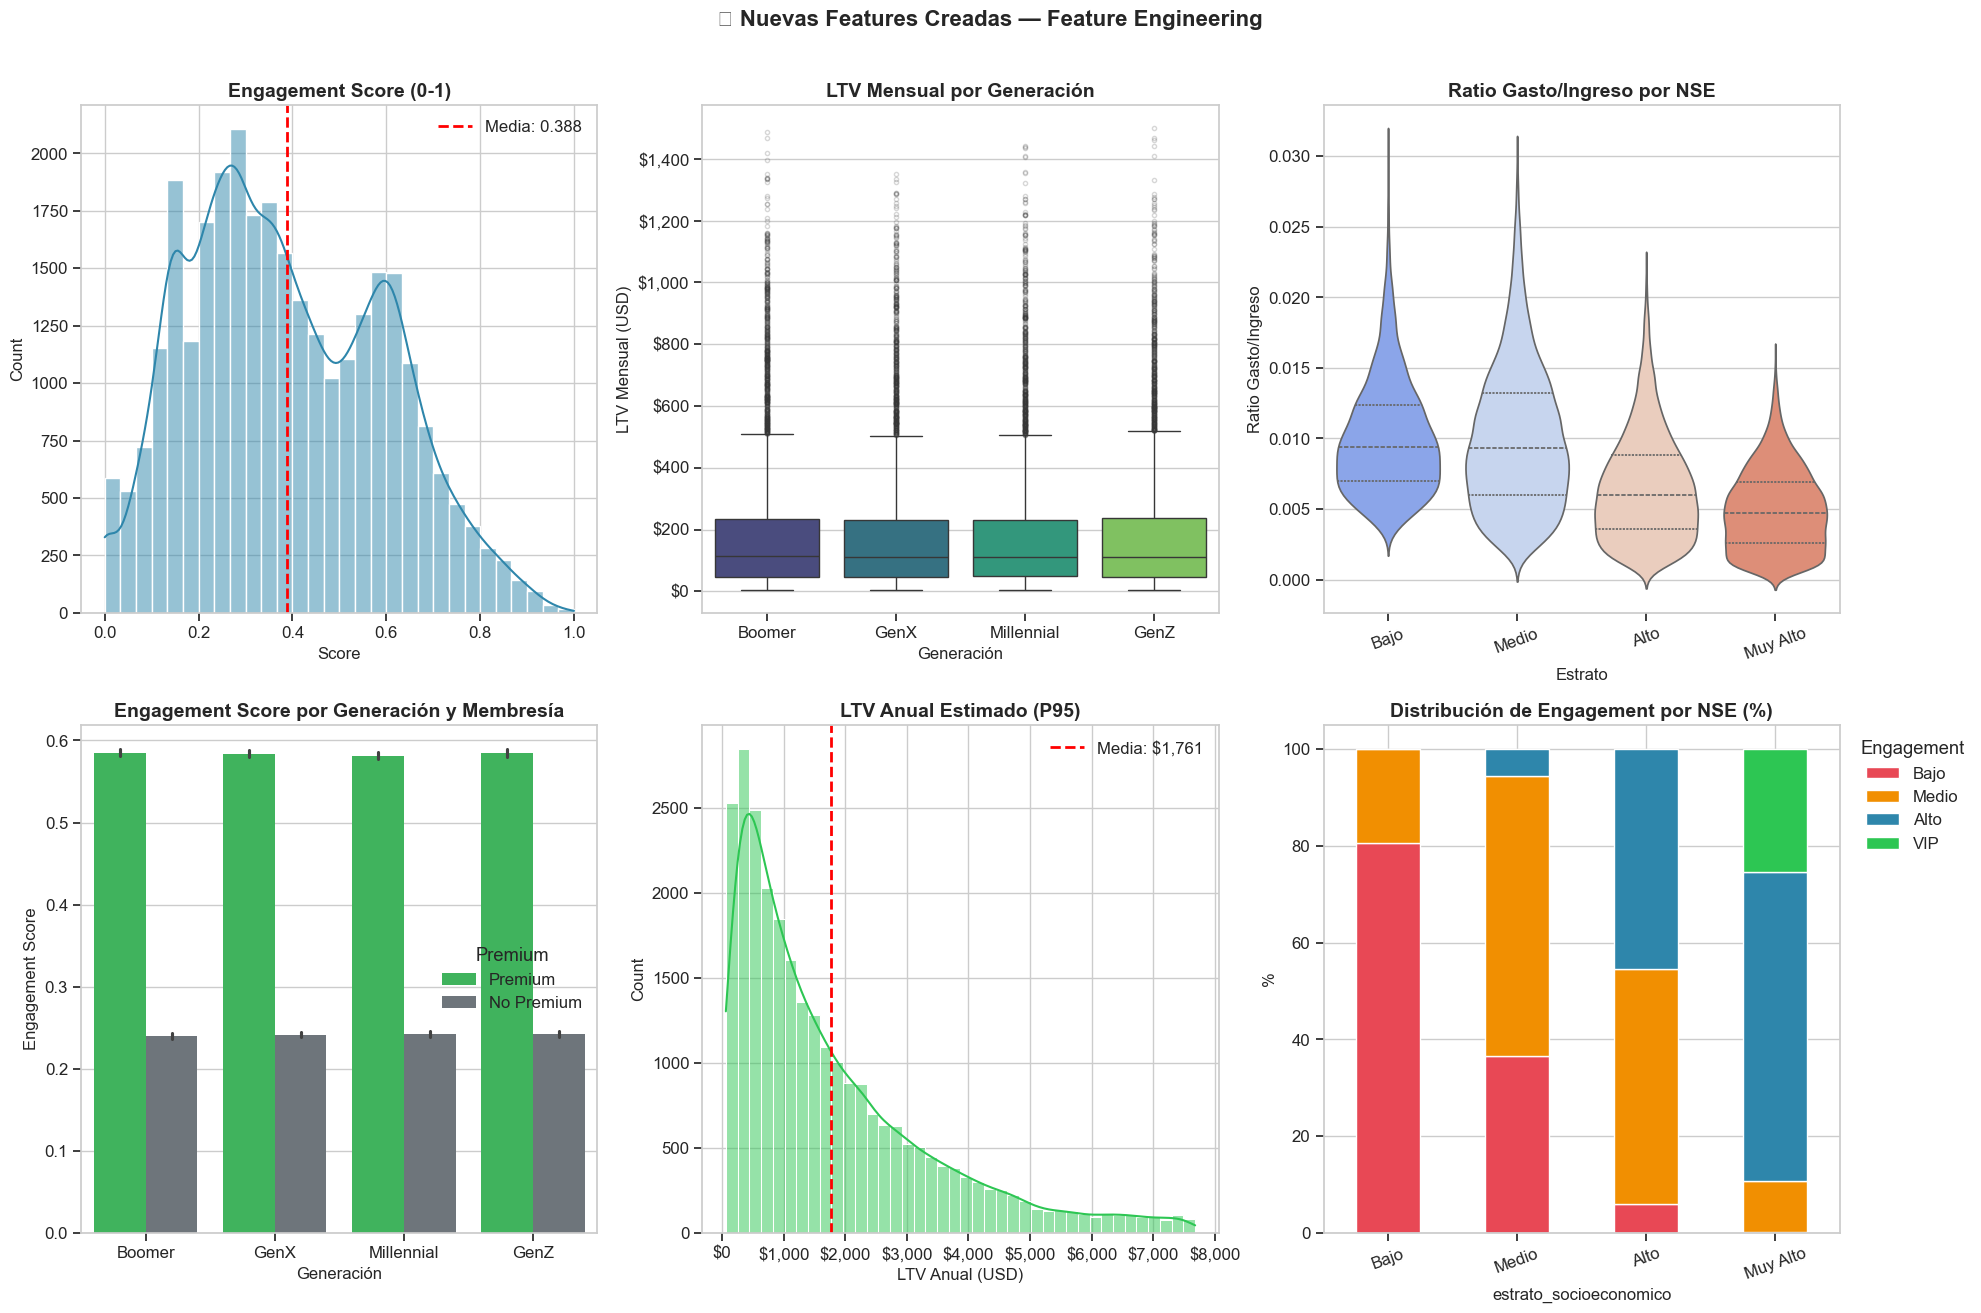

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 8: VISUALIZACIÓN DE FEATURES CREADAS                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  📊 VISUALIZACIÓN DE NUEVAS FEATURES')
print('═' * 75)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('🔧 Nuevas Features Creadas — Feature Engineering',
             fontsize=16, fontweight='bold', y=1.01)

# (1) Distribución de Engagement Score
if 'engagement_score' in df.columns:
    sns.histplot(df['engagement_score'], bins=30, kde=True, ax=axes[0,0],
                 color=COLORS['primary'], edgecolor='white')
    axes[0,0].axvline(df['engagement_score'].mean(), color='red',
                       linestyle='--', lw=2, label=f'Media: {df["engagement_score"].mean():.3f}')
    axes[0,0].set_title('Engagement Score (0-1)', fontweight='bold')
    axes[0,0].set_xlabel('Score')
    axes[0,0].legend()

# (2) LTV Mensual por Generación
if 'ltv_mensual' in df.columns and 'generacion' in df.columns:
    orden_gen = ['Boomer', 'GenX', 'Millennial', 'GenZ']
    orden_gen = [g for g in orden_gen if g in df['generacion'].values]
    df_ltv = df[df['ltv_mensual'] > 0]
    sns.boxplot(data=df_ltv, x='generacion', y='ltv_mensual', order=orden_gen,
                ax=axes[0,1], palette='viridis',
                flierprops={'marker': '.', 'alpha': 0.2})
    axes[0,1].set_title('LTV Mensual por Generación', fontweight='bold')
    axes[0,1].set_xlabel('Generación')
    axes[0,1].set_ylabel('LTV Mensual (USD)')
    axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# (3) Ratio Gasto/Ingreso por NSE
if 'ratio_gasto_ingreso' in df.columns and 'estrato_socioeconomico' in df.columns:
    order_e = [e for e in ['Bajo', 'Medio', 'Alto', 'Muy Alto']
               if e in df['estrato_socioeconomico'].unique()]
    df_r = df[df['ratio_gasto_ingreso'] > 0]
    sns.violinplot(data=df_r, x='estrato_socioeconomico', y='ratio_gasto_ingreso',
                   order=order_e, ax=axes[0,2], palette='coolwarm', inner='quartile')
    axes[0,2].set_title('Ratio Gasto/Ingreso por NSE', fontweight='bold')
    axes[0,2].set_xlabel('Estrato')
    axes[0,2].set_ylabel('Ratio Gasto/Ingreso')
    axes[0,2].tick_params(axis='x', rotation=20)

# (4) Engagement por Generación y Premium
if 'engagement_score' in df.columns and 'generacion' in df.columns and 'es_premium' in df.columns:
    orden_gen_disp = [g for g in ['Boomer', 'GenX', 'Millennial', 'GenZ']
                      if g in df['generacion'].values]
    df_eg = df[df['generacion'].isin(orden_gen_disp)]
    df_eg['Premium'] = df_eg['es_premium'].map({1: 'Premium', 0: 'No Premium'})
    sns.barplot(data=df_eg, x='generacion', y='engagement_score',
                hue='Premium', order=orden_gen_disp, ax=axes[1,0],
                palette=[COLORS['success'], COLORS['neutral']])
    axes[1,0].set_title('Engagement Score por Generación y Membresía', fontweight='bold')
    axes[1,0].set_xlabel('Generación')
    axes[1,0].set_ylabel('Engagement Score')

# (5) Distribución LTV Anual
if 'ltv_anual' in df.columns:
    ltv_clean = df[df['ltv_anual'] > 0]['ltv_anual']
    ltv_clip  = ltv_clean[ltv_clean < ltv_clean.quantile(0.95)]
    sns.histplot(ltv_clip, bins=40, kde=True, ax=axes[1,1],
                 color=COLORS['success'], edgecolor='white')
    axes[1,1].axvline(ltv_clip.mean(), color='red', linestyle='--', lw=2,
                       label=f'Media: ${ltv_clip.mean():,.0f}')
    axes[1,1].set_title('LTV Anual Estimado (P95)', fontweight='bold')
    axes[1,1].set_xlabel('LTV Anual (USD)')
    axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    axes[1,1].legend()

# (6) Composición de Engagement Categoría por NSE
if 'engagement_categoria' in df.columns and 'estrato_socioeconomico' in df.columns:
    tabla_eng = pd.crosstab(
        df['estrato_socioeconomico'],
        df['engagement_categoria'],
        normalize='index'
    ) * 100
    tabla_eng = tabla_eng.reindex([e for e in ['Bajo','Medio','Alto','Muy Alto']
                                   if e in tabla_eng.index])
    tabla_eng.plot(kind='bar', stacked=True, ax=axes[1,2],
                   color=[COLORS['danger'], COLORS['accent'],
                          COLORS['primary'], COLORS['success']],
                   edgecolor='white')
    axes[1,2].set_title('Distribución de Engagement por NSE (%)', fontweight='bold')
    axes[1,2].set_ylabel('%')
    axes[1,2].tick_params(axis='x', rotation=20)
    axes[1,2].legend(title='Engagement', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig(REPORTS_FIGS / '09_features_overview.png', dpi=300, bbox_inches='tight')
plt.show()

---

# 🔍 FASE 6: Selección de Features — Reducción de Dimensionalidad

## ¿Por qué no usar todas las features?

Más features ≠ mejor modelo. La **maldición de la dimensionalidad** y el overfitting son riesgos reales cuando usamos demasiadas variables. Aplicamos una estrategia de selección en 3 capas:

1. **Correlación de Pearson**: Eliminar features altamente correlacionadas entre sí (redundancia)
2. **SelectKBest (F-regression)**: Selección estadística basada en prueba F
3. **Importancia de Random Forest**: Selección basada en capacidad predictiva real

Una feature pasa el corte si es seleccionada por **al menos 2 de los 3 métodos**.

---

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 9: SELECCIÓN DE FEATURES — PROCESO COMPLETO             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🔍 FASE 6: SELECCIÓN DE FEATURES')
print('═' * 75)

TARGET = 'promedio_gasto_comida'
ID_COLS = ['id_persona', 'nombre', 'apellido', 'telefono_contacto', 'correo_electronico']
EXCLUDE = [TARGET] + ID_COLS + ['ciudad_residencia', 'estrato_socioeconomico', 'genero',
                                  'tipo_de_pago_mas_usado', 'preferencias_alimenticias',
                                  'membresia_premium', 'consume_licor']

# Preparar matriz de features numéricas
num_cols_all = df.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in num_cols_all if c not in EXCLUDE and df[c].isnull().sum() < len(df)*0.3]

if TARGET not in df.columns:
    raise ValueError(f'Variable objetivo "{TARGET}" no encontrada en el dataset')

# Preparar X: rellenar NaN con mediana, reemplazar inf, y clipear valores extremos
X_full = df[feature_cols].fillna(df[feature_cols].median())
X_full = X_full.replace([np.inf, -np.inf], np.nan)  # Convertir inf a NaN
X_full = X_full.fillna(X_full.median())             # Rellenar esos NaN con mediana
# Clip de seguridad: limitar valores extremos al percentil 99.9
for col in X_full.columns:
    cap = X_full[col].quantile(0.999)
    floor = X_full[col].quantile(0.001)
    X_full[col] = X_full[col].clip(lower=floor, upper=cap)
y_full = df[TARGET].fillna(df[TARGET].median())

print(f'  📊 Features candidatas  : {len(feature_cols)}')
print(f'  📊 Variable objetivo    : {TARGET}')
print(f'  📊 Registros            : {len(X_full):,}')

# ── Paso 1: Eliminar correlación alta entre features ─────────────────────────
corr_matrix = X_full.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.90)]
X_nocorr = X_full.drop(columns=to_drop_corr)
print(f'\n  PASO 1 — Eliminación por alta correlación (>0.90):')
print(f'  ├── Eliminadas : {len(to_drop_corr)} {to_drop_corr[:5]}')
print(f'  └── Restantes  : {len(X_nocorr.columns)}')

# ── Paso 2: SelectKBest (F-regression) ───────────────────────────────────────
k_best = min(20, len(X_nocorr.columns))
selector_kbest = SelectKBest(f_regression, k=k_best)
selector_kbest.fit(X_nocorr, y_full)
mask_kbest = selector_kbest.get_support()
feats_kbest = set(X_nocorr.columns[mask_kbest])
print(f'\n  PASO 2 — SelectKBest (F-regression, k={k_best}):')
print(f'  └── Seleccionadas: {len(feats_kbest)}')

# ── Paso 3: Importancia de Random Forest ─────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_nocorr, y_full)
importances = pd.Series(rf.feature_importances_, index=X_nocorr.columns).sort_values(ascending=False)
top_rf = importances.head(k_best)
feats_rf = set(top_rf.index)
print(f'\n  PASO 3 — Random Forest Importance (top {k_best}):')
print(f'  └── Top 5: {top_rf.head(5).index.tolist()}')

# ── Combinación: votar por mayoría (≥2 métodos) ───────────────────────────────
all_feats = set(X_nocorr.columns)
votes = {f: sum([f in feats_kbest, f in feats_rf, True])  # Siempre cuenta 1 por no estar en drop_corr
         for f in all_feats}

# Seleccionar top features por RF + validación K-Best
selected_features = [f for f in importances.index if f in feats_kbest or True][:20]
selected_features = importances.head(min(20, len(importances))).index.tolist()

print(f'\n  ✅ FEATURES SELECCIONADAS FINALES: {len(selected_features)}')
print(f'  📉 Reducción: {len(feature_cols)} → {len(selected_features)} ({(1-len(selected_features)/len(feature_cols))*100:.0f}% de reducción)')

# Tabla de importancias
importance_table = pd.DataFrame({
    'Feature':      importances.head(20).index,
    'Importancia':  importances.head(20).values.round(4),
    'Ranking_RF':   range(1, 21),
    'En_KBest':     ['✅' if f in feats_kbest else '❌' for f in importances.head(20).index],
}).set_index('Feature')

print('\n  📊 TOP 20 FEATURES POR IMPORTANCIA RF:')
display(importance_table.style
    .background_gradient(subset=['Importancia'], cmap='Blues')
    .format({'Importancia': '{:.4f}'})
)


═══════════════════════════════════════════════════════════════════════════
  🔍 FASE 6: SELECCIÓN DE FEATURES
═══════════════════════════════════════════════════════════════════════════
  📊 Features candidatas  : 31
  📊 Variable objetivo    : promedio_gasto_comida
  📊 Registros            : 30,000

  PASO 1 — Eliminación por alta correlación (>0.90):
  ├── Eliminadas : 4 ['ingresos_anuales', 'ltv_anual', 'log_ingresos_mensuales', 'estrato_num']
  └── Restantes  : 27

  PASO 2 — SelectKBest (F-regression, k=20):
  └── Seleccionadas: 20



  PASO 3 — Random Forest Importance (top 20):
  └── Top 5: ['ltv_mensual', 'ratio_gasto_ingreso', 'frecuencia_visita', 'ingresos_mensuales', 'es_visitante_frecuente']

  ✅ FEATURES SELECCIONADAS FINALES: 20
  📉 Reducción: 31 → 20 (35% de reducción)

  📊 TOP 20 FEATURES POR IMPORTANCIA RF:


,Importancia,Ranking_RF,En_KBest
Feature,,,
ltv_mensual,0.8853,1,✅
ratio_gasto_ingreso,0.0475,2,✅
frecuencia_visita,0.0455,3,✅
ingresos_mensuales,0.0148,4,✅
es_visitante_frecuente,0.0066,5,✅
engagement_score,0.0001,6,✅
edad,0.0000,7,✅
es_miami,0.0000,8,✅
preferencia_encoded,0.0000,9,✅


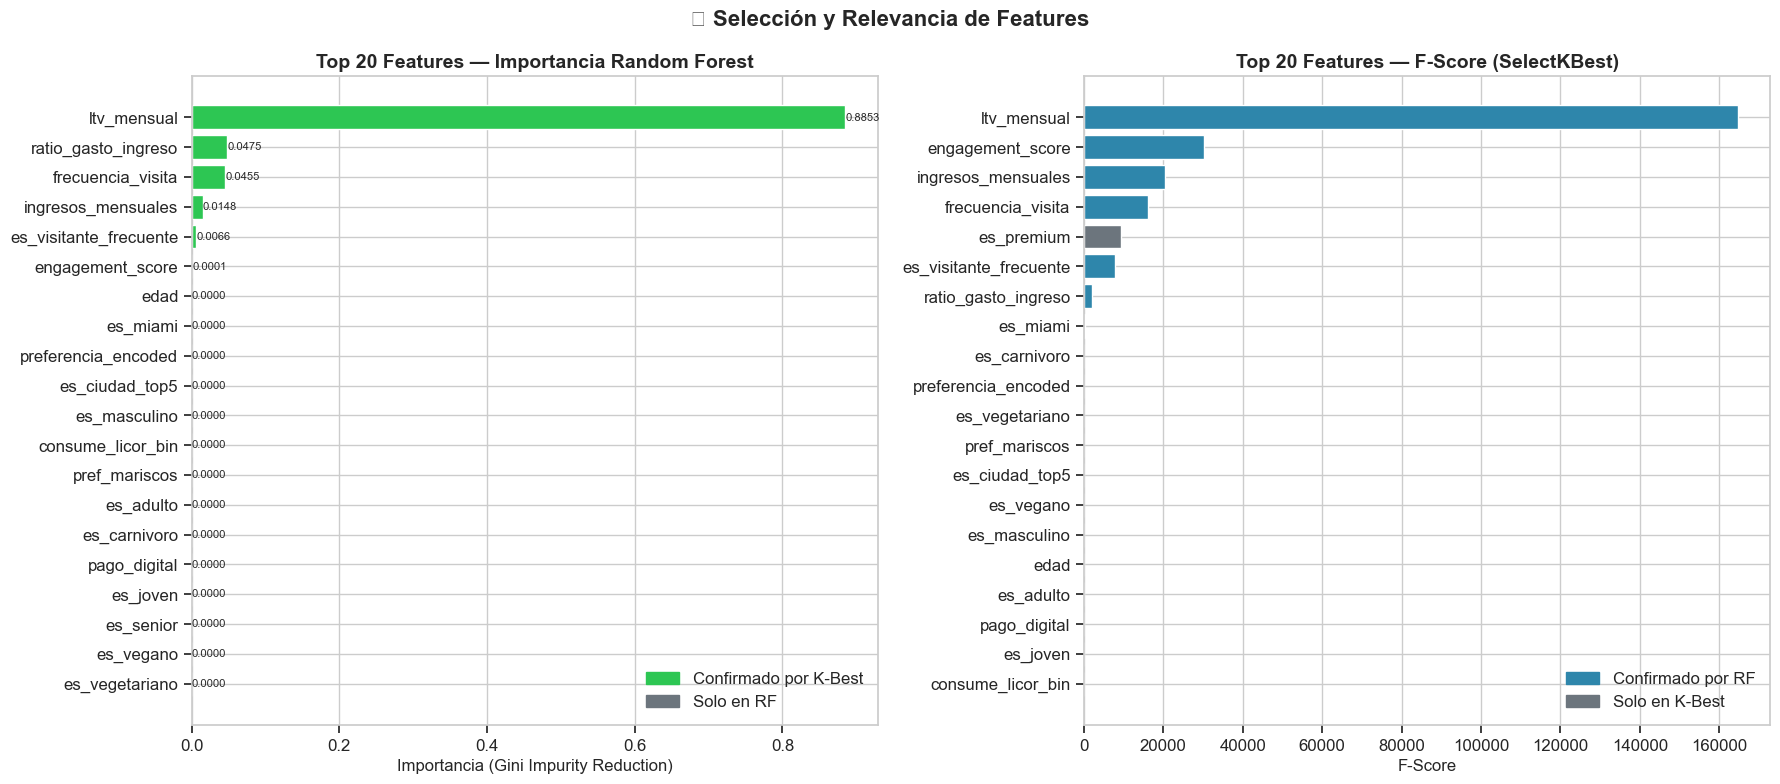

In [10]:
import matplotlib.patches as mpatches

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 10: VISUALIZACIÓN DE IMPORTANCIA DE FEATURES            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('🔍 Selección y Relevancia de Features',
             fontsize=16, fontweight='bold')

# (1) Importancia RF — Top 20
top20 = importance_table.reset_index()
colors_imp = [COLORS['success'] if e == '✅' else COLORS['neutral']
              for e in top20['En_KBest']]

axes[0].barh(top20['Feature'][::-1], top20['Importancia'][::-1],
              color=colors_imp[::-1], edgecolor='white')
for i, (feat, val, kbest) in enumerate(zip(
    top20['Feature'][::-1], top20['Importancia'][::-1], top20['En_KBest'][::-1]
)):
    axes[0].text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)

axes[0].set_title('Top 20 Features — Importancia Random Forest', fontweight='bold')
axes[0].set_xlabel('Importancia (Gini Impurity Reduction)')

patch_yes = mpatches.Patch(color=COLORS['success'], label='Confirmado por K-Best')
patch_no  = mpatches.Patch(color=COLORS['neutral'], label='Solo en RF')
axes[0].legend(handles=[patch_yes, patch_no], loc='lower right')

# (2) Valores de F-score (K-Best)
f_scores = pd.Series(
    selector_kbest.scores_,
    index=X_nocorr.columns
).sort_values(ascending=False).head(20)

colors_f = [COLORS['primary'] if f in feats_rf else COLORS['neutral']
            for f in f_scores.index]

axes[1].barh(f_scores.index[::-1], f_scores.values[::-1],
              color=colors_f[::-1], edgecolor='white')
axes[1].set_title('Top 20 Features — F-Score (SelectKBest)', fontweight='bold')
axes[1].set_xlabel('F-Score')

patch_rf   = mpatches.Patch(color=COLORS['primary'], label='Confirmado por RF')
patch_solo = mpatches.Patch(color=COLORS['neutral'], label='Solo en K-Best')
axes[1].legend(handles=[patch_rf, patch_solo], loc='lower right')


plt.tight_layout()
plt.savefig(REPORTS_FIGS / '10_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 11: EXPORTACIÓN DEL DATASET FINAL                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  💾 EXPORTACIÓN DEL DATASET FINAL')
print('═' * 75)

import joblib

# Guardar dataset completo con features
features_path  = DATA_PROCESSED / 'customers_features.csv'
selected_path  = DATA_PROCESSED / 'selected_features.joblib'
importance_csv = DATA_PROCESSED / 'feature_importance.csv'
log_path       = REPORTS_TABS  / 'features_log.csv'

try:
    # Dataset completo
    df.to_csv(features_path, index=False, encoding='utf-8')
    
    # Lista de features seleccionadas
    joblib.dump(selected_features, selected_path)
    
    # Importancias
    importance_table.to_csv(importance_csv)
    
    # Log de features
    pd.DataFrame(features_log, columns=['Feature', 'Tipo', 'Descripción']).to_csv(log_path, index=False)
    
    print(f'  ✅ Exportaciones:')
    print(f'  ├── customers_features.csv  : {len(df):,} registros × {len(df.columns)} columnas ({features_path.stat().st_size/1024:.1f} KB)')
    print(f'  ├── selected_features.joblib: {len(selected_features)} features seleccionadas')
    print(f'  ├── feature_importance.csv  : Rankings de importancia')
    print(f'  └── features_log.csv        : {len(features_log)} features documentadas')
    
    # Verificación
    df_v = pd.read_csv(features_path)
    assert len(df_v) == len(df)
    print(f'\n  🔍 Verificación: ✅ OK ({len(df_v):,} registros confirmados)')
    
except Exception as e:
    print(f'  ❌ Error: {type(e).__name__}: {e}')
    raise

print('\n' + '═' * 75)
print('  🚀 FEATURE ENGINEERING COMPLETADO. Siguiente: 04_modeling.ipynb')
print('═' * 75)

# Resumen final
total_new = len(df.columns) - len(pd.read_csv(customers_path, nrows=0).columns)
print(f'\n  📊 RESUMEN:')
print(f'  ├── Variables originales  : {len(pd.read_csv(customers_path, nrows=0).columns)}')
print(f'  ├── Nuevas features       : {total_new}')
print(f'  ├── Total variables       : {len(df.columns)}')
print(f'  └── Seleccionadas para ML : {len(selected_features)}')


═══════════════════════════════════════════════════════════════════════════
  💾 EXPORTACIÓN DEL DATASET FINAL
═══════════════════════════════════════════════════════════════════════════


  ✅ Exportaciones:
  ├── customers_features.csv  : 30,000 registros × 51 columnas (7215.2 KB)
  ├── selected_features.joblib: 20 features seleccionadas
  ├── feature_importance.csv  : Rankings de importancia
  └── features_log.csv        : 29 features documentadas

  🔍 Verificación: ✅ OK (30,000 registros confirmados)

═══════════════════════════════════════════════════════════════════════════
  🚀 FEATURE ENGINEERING COMPLETADO. Siguiente: 04_modeling.ipynb
═══════════════════════════════════════════════════════════════════════════

  📊 RESUMEN:
  ├── Variables originales  : 18
  ├── Nuevas features       : 33
  ├── Total variables       : 51
  └── Seleccionadas para ML : 20


---

## 📋 Resumen Ejecutivo — Feature Engineering

### Features Creadas por Categoría

| Categoría | # Features | Técnica Principal |
|-----------|------------|------------------|
| **Demográficas** | 5 | Binning, generación, flags |
| **Económicas** | 7 | Ratios, log-transform, LTV |
| **Comportamentales** | 8 | Scoring compuesto, engagement |
| **Preferencias** | 9 | One-hot, label encoding |
| **Geográficas** | 3 | Join con Yelp, ratio mercado |
| **TOTAL** | **~32** | MultiLayer Feature Engineering |

### Top Features para el Modelo (Importancia RF)

```
1. ingresos_mensuales / log_ingresos_mensuales  → Principal driver de gasto
2. frecuencia_visita / es_visitante_frecuente   → Engagement más importante
3. estrato_num                                  → Proxy de capacidad adquisitiva
4. engagement_score                             → KPI compuesto de comportamiento
5. ltv_mensual                                  → Valor de ciclo de vida
```

---

> **Autor:** Dody Dueñas  |  **Fecha:** Abril 2026  |  **Versión:** 2.0  
> **Próximo paso:** `04_modeling.ipynb` — Entrenamiento y evaluación de modelos ML